In [1]:
import edes 
from edes.utils.plotting import plot, plot_ax, big_plt_font, plot_ax_errbar, plot_errbar
from edes.utils.plotting import plot_generated_timelines, generate_signal_timeline
from edes.utils.circuits import dBm_to_W, W_to_dBm
import numpy as np 
from tqdm import tqdm, trange 
import matplotlib.pyplot as plt 
import time
import pandas as pd
from edes.utils.file_handling import load_h5_data, load_latest_data, load_latest_filename, list_filenames
import re
big_plt_font()

In [2]:
data_dir = '/home/electron/data/experiment_07072026'
all_files = list_filenames(data_dir)

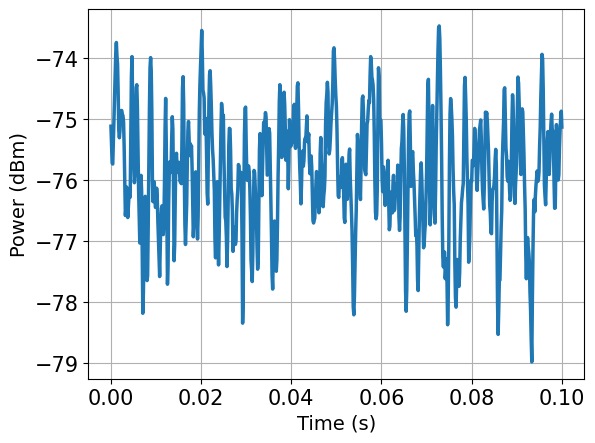

In [5]:
file = load_latest_data() 
data = file['all_meas'] 
t_seq_end = file['t_data']
t_axis = np.linspace(0, t_seq_end, len(data[0])) 
data_avg = np.mean(data, axis=0) 
plot(t_axis, data_avg, xlabel='Time (s)', ylabel='Power (dBm)')

In [5]:
file['filename']

'/home/electron/data/experiment_07072026/RFPowerSweepOnOff_11-01-45.h5'

In [29]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- Your existing data setup remains here ---
# (Ensure t_axis and data are defined above this cell)
file = load_h5_data('/home/electron/data/experiment_07062026/RFPowerSweepOnOff_18-11-16_data.h5') #load_latest_data() #
data = file['all_meas'] 
t_seq_end = file['t_data']
t_axis = np.linspace(0, t_seq_end, len(data[0])) 

# 1. Setup UI elements (Slider and Navigation Buttons)
slider = widgets.IntSlider(
    value=0, 
    min=0, 
    max=len(data) - 1, 
    step=1, 
    description='Index (i):'
)

btn_prev = widgets.Button(
    description='Prev',
    button_style='info',     # Light blue styling
    icon='arrow-left'        # Left arrow icon
)

btn_next = widgets.Button(
    description='Next',
    button_style='primary',  # Darker blue styling
    icon='arrow-right'       # Right arrow icon
)

# Output container to catch the plot and refresh it cleanly
plot_output = widgets.Output()

# 2. Plotting logic wrapped in an output handler
def draw_plot(i):
    with plot_output:
        clear_output(wait=True)  # Instantly clears the old plot
        
        fig, ax = plt.subplots(figsize=(7, 4))
        # Using your exact variables and scalings
        ax.plot(t_axis * 1e3, data[i], color='blue', lw=2)
        
        ax.set_title(f"Plotting dataset i = {i}")
        ax.set_xlabel("Wait time (ms)")
        ax.set_ylabel("Power (dBm)")
        ax.grid(True)
        plt.show()

# 3. Define event behaviors
def on_slider_change(change):
    draw_plot(change['new'])

def on_next_clicked(b):
    # Advances the slider, looping back to 0 if at the end
    if slider.value < slider.max:
        slider.value += 1
    else:
        slider.value = 0

def on_prev_clicked(b):
    # Rewinds the slider, looping to the end if at 0
    if slider.value > slider.min:
        slider.value -= 1
    else:
        slider.value = slider.max

# Link actions to the widgets
slider.observe(on_slider_change, names='value')
btn_next.on_click(on_next_clicked)
btn_prev.on_click(on_prev_clicked)

# 4. Pack layouts in a clean media-player style order and display
controls = widgets.HBox([btn_prev, slider, btn_next])
ui = widgets.VBox([controls, plot_output])

display(ui)

# Render the very first plot upon cell execution
draw_plot(slider.value)

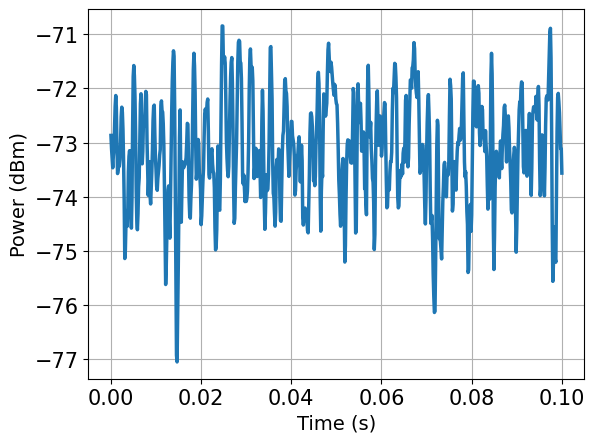

In [118]:
file2 = load_h5_data('data/experiment_07072026/RFPowerSweepOnOff_19-17-20.h5', base='/home/electron/') 
data2 = file2['all_meas'] 
t_seq_end2 = file2['t_data']
t_axis2 = np.linspace(0, t_seq_end2, len(data2[0])) 
data_avg2 = np.mean(data2, axis=0) 
plot(t_axis2, data_avg2, xlabel='Time (s)', ylabel='Power (dBm)')

NameError: name 't_axis2' is not defined

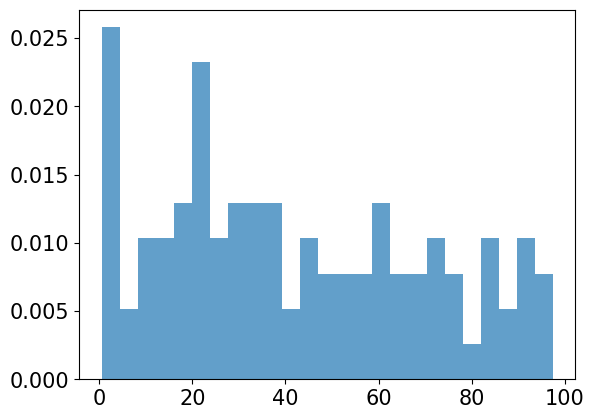

In [21]:
peak_time = []
for i in range(len(data)): 
    peak_time.append(t_axis[np.argmax(data[i])]*1e3) 
plt.hist(peak_time, bins=25, lw=2, label='Tip on', alpha=0.7, density=True)
peak_time = []
for i in range(len(data2)): 
    peak_time.append(t_axis2[np.argmax(data2[i])]*1e3) 
plt.hist(peak_time, bins=25, lw=2, label='Tip off', alpha=0.7, density=True)
plt.xlabel('Time at which max power is detected (ms)') 
plt.ylabel('Counts density / 4ms bin') 
plt.legend()
plt.grid() 
plt.show()

In [71]:
file2['filename']

'/home/electron/data/experiment_07062026/RFPowerSweepOnOff_19-06-42.h5'

In [26]:
np.shape(P_nW)

(100,)

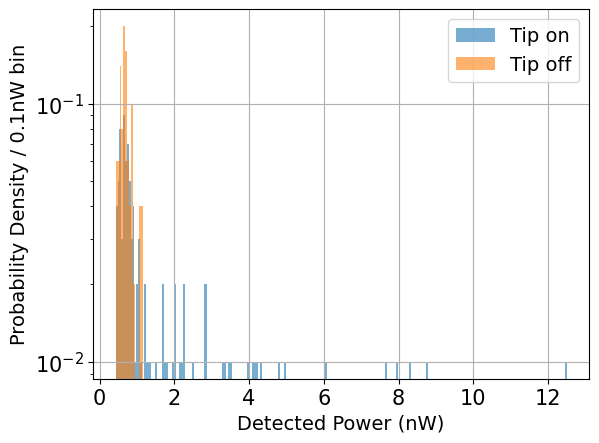

In [28]:
file = load_h5_data('/home/electron/data/experiment_07062026/RFPowerSweepOnOff_18-11-16_data.h5') #load_latest_data()#
data = file['all_meas'] 
file2 = load_h5_data('data/experiment_07062026/RFPowerSweepOnOff_19-06-42_data.h5', base='/home/electron/') 
data2 = file2['all_meas'] 
P_nW = dBm_to_W(np.max(data, axis=1))*1e9 
P_nW_background = dBm_to_W(np.max(data2, axis=1))*1e9
bin_size = 0.05

counts, bin_edges = np.histogram(P_nW, bins=int((max(P_nW)-min(P_nW))/bin_size))#, alpha=0.7, label='Tip on')
plt.bar(
    bin_edges[:-1],          # X-coordinates: Use all edges except the very last one
    counts/np.sum(counts),                  # Y-coordinates: The heights of the bars
    width=np.diff(bin_edges),# Width of each bar (difference between adjacent edges)
    label='Tip on',
    align='edge',            # Align the bars to start at the left bin edge
    alpha=0.6                # Transparency
)

counts, bin_edges = np.histogram(P_nW_background, bins=int((max(P_nW_background)-min(P_nW_background))/bin_size))#, alpha=0.7, label='Tip off')
# plt.xscale('log') 
plt.bar(
    bin_edges[:-1],          # X-coordinates: Use all edges except the very last one
    counts/np.sum(counts),                  # Y-coordinates: The heights of the bars
    width=np.diff(bin_edges),# Width of each bar (difference between adjacent edges)
    label='Tip off',
    align='edge',            # Align the bars to start at the left bin edge
    alpha=0.6                # Transparency
)



plt.yscale('log')
plt.xlabel('Detected Power (nW)') 
plt.ylabel('Probability Density / 0.1nW bin')
plt.grid()
plt.legend()
plt.show()

In [20]:
P_th = np.mean(P_nW_background)+10*np.std(P_nW_background) # nW
print(P_th)
print(np.mean(P_nW_background))
print(np.std(P_nW_background))
sum([1 for i in dBm_to_W(file['all_meas'])*1e9 if np.any(i > P_th)])/len(file['all_meas']) 

1.2272342806399712
0.1178213123554329
0.11094129682845384


0.37

In [17]:
sum([1 for i in dBm_to_W(file2['all_meas'])*1e9 if np.any(i > P_th)])/len(file2['all_meas'])

0.0

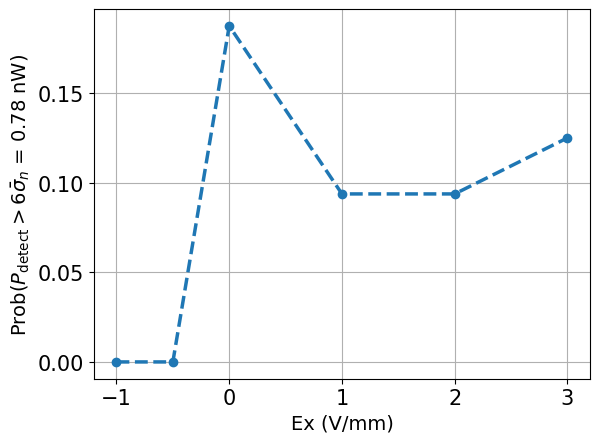

In [101]:
all_files = list_filenames(data_dir)
all_meas = {}
P_th = np.mean(P_nW_background)+6*np.std(P_nW_background) # nW
for file in all_files: 
    if "RFPowerSweepOnOff" in file:# and file[-11:-3] < '13-20-00': 
        file = load_h5_data(file, base=data_dir) 
        data = np.concatenate(dBm_to_W(file['all_meas'])*1e9, axis=0)
        metric = sum([1 for i in dBm_to_W(file['all_meas'])*1e9 if np.any(i > P_th)])/len(file['all_meas'])
        # metric = len(data[np.where(data > P_th)])/len(data)
        t_seq_end = file['t_data']
        if file['Ex'] in all_meas:
            all_meas[file['Ex']].append( [file['U2'], metric] )
        else:
            all_meas[file['Ex']] = [[file['U2'], metric]]

Ex = [i for i in all_meas] 
data = [] 
for i in all_meas: 
    for j in range(len(all_meas[i])): 
        if all_meas[i][j][0] == -0.4: 
            data.append(all_meas[i][j][1])
            break
# data = [all_meas[i][0][1] for i in all_meas if abs(all_meas[i][0][0]+0.4) <= 0.05]
sort_idx = np.argsort(np.array(Ex))
plot(np.array(Ex)[sort_idx], np.array(data)[sort_idx], '.--', xlabel='Ex (V/mm)', ylabel=r'Prob($P_{\text{detect}} > 6\bar{\sigma}_n$'+f' = {P_th:.2f} nW)')
# plt.yscale('log')

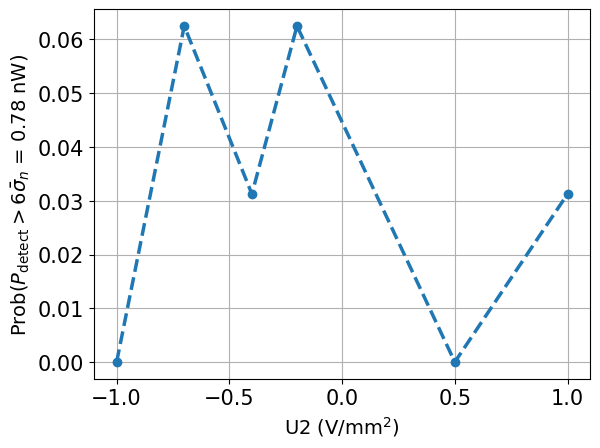

In [106]:
all_files = list_filenames(data_dir)
all_meas = {}
P_th = np.mean(P_nW_background)+6*np.std(P_nW_background) # nW
for file in all_files: 
    if "RFPowerSweepOnOff" in file and file[-11:-3] > '13-20-00': 
        file = load_h5_data(file, base=data_dir) 
        # data = np.concatenate(dBm_to_W(file['all_meas'])*1e9, axis=0)
        metric = sum([1 for i in dBm_to_W(file['all_meas'])*1e9 if np.any(i > P_th)])/len(file['all_meas'])
        # metric = len(data[np.where(data > P_th)])/len(data)
        t_seq_end = file['t_data']
        if file['Ex'] in all_meas:
            all_meas[file['Ex']].append( [file['U2'], metric] )
        else:
            all_meas[file['Ex']] = [[file['U2'], metric]]

U2, data = np.array(all_meas[0]).T
sort_idx = np.argsort(U2)
plot(np.array(U2)[sort_idx], np.array(data)[sort_idx], '.--', xlabel=r'U2 (V/mm$^2$)', ylabel=r'Prob($P_{\text{detect}} > 6\bar{\sigma}_n$'+f' = {P_th:.2f} nW)')
# plt.yscale('log')

In [76]:
all_meas

{np.int64(0): [[np.float64(-0.2), 0.0625],
  [np.int64(-1), 0.0],
  [np.float64(0.5), 0.0],
  [np.float64(-0.4), 0.03125],
  [np.float64(-0.7), 0.0625]]}

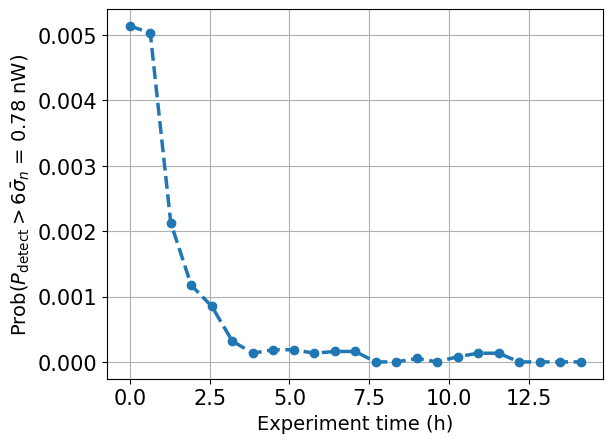

In [258]:
all_files = list_filenames(data_dir)
all_meas = {}
P_th = np.mean(P_nW_background)+6*np.std(P_nW_background) # nW
for file in all_files: 
    if "RFPowerSweepOnOff" in file and "old" not in file and "data" not in file: 
        file = load_h5_data(file, base=data_dir) 
        data = np.concatenate(dBm_to_W(file['all_meas'])*1e9, axis=0)
        t_seq_end = file['t_data']
        if file['Ex'] in all_meas:
            all_meas[file['Ex']].append( [file['U2'], len(data[np.where(data > P_th)])/len(data)] )
        else:
            all_meas[file['Ex']] = [[file['U2'], len(data[np.where(data > P_th)])/len(data)]]
all_data = []
for Ex in np.sort(list(all_meas.keys()))[::-1]: 
    U2, data = np.array(all_meas[Ex]).T
    sort_idx = np.argsort(U2) 
    all_data.extend(np.array(data)[sort_idx])
plot(np.arange(len(all_data))*38.5/60, all_data, '.--', xlabel='Experiment time (h)', ylabel=r'Prob($P_{\text{detect}} > 6\bar{\sigma}_n$'+f' = {P_th:.2f} nW)')
# plt.yscale('log')

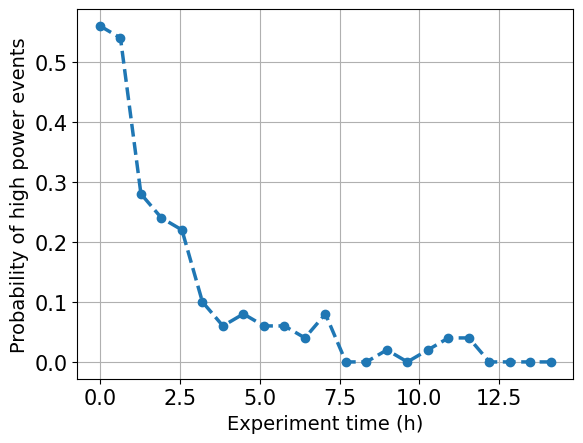

In [261]:
all_files = list_filenames(data_dir)
all_meas = {}
P_th = np.mean(P_nW_background)+6*np.std(P_nW_background) # nW
for file in all_files: 
    if "RFPowerSweepOnOff" in file and "old" not in file and "data" not in file: 
        file = load_h5_data(file, base=data_dir) 
        data = sum([1 for i in dBm_to_W(file['all_meas'])*1e9 if np.any(i > P_th)])/len(file['all_meas'])
        t_seq_end = file['t_data']
        if file['Ex'] in all_meas:
            all_meas[file['Ex']].append( [file['U2'], data] )
        else:
            all_meas[file['Ex']] = [[file['U2'], data]]
all_data = []
for Ex in np.sort(list(all_meas.keys()))[::-1]: 
    U2, data = np.array(all_meas[Ex]).T
    sort_idx = np.argsort(U2) 
    all_data.extend(np.array(data)[sort_idx])
plot(np.arange(len(all_data))*38.5/60, all_data, '.--', xlabel='Experiment time (h)', ylabel=r'Probability of high power events')
# plt.yscale('log')

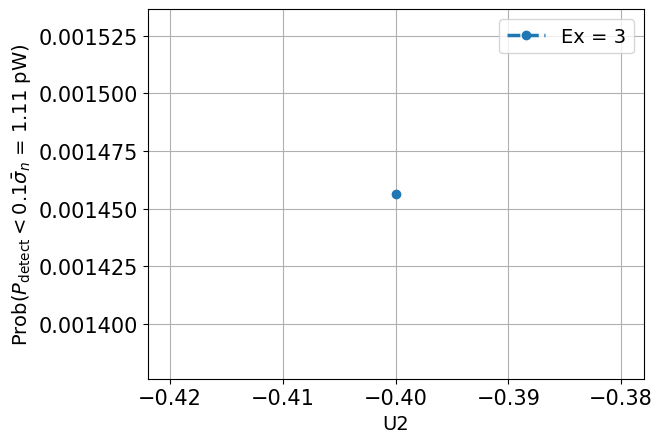

In [12]:
all_files = list_filenames(data_dir)
all_meas = {}
P_th = 0.01*np.std(P_nW_background) # nW
for file in all_files: 
    if "RFPowerSweepOnOff" in file and "old" not in file and "data" not in file: 
        file = load_h5_data(file, base=data_dir) 
        data = np.concatenate(dBm_to_W(file['all_meas'])*1e9, axis=0)
        t_seq_end = file['t_data']
        if file['Ex'] in all_meas:
            all_meas[file['Ex']].append( [file['U2'], len(data[np.where(data < P_th)])/len(data)] )
        else:
            all_meas[file['Ex']] = [[file['U2'], len(data[np.where(data < P_th)])/len(data)]]

for Ex in all_meas: 
    U2, data = np.array(all_meas[Ex]).T
    sort_idx = np.argsort(U2) 
    plot(np.array(U2)[sort_idx], np.array(data)[sort_idx], '.--', label=f'Ex = {Ex}', xlabel='U2', ylabel=r'Prob($P_{\text{detect}} < 0.1\bar{\sigma}_n$'+f' = {P_th*1e3:.2f} pW)')
# plt.yscale('log')